# Diabetes Risk Prediction

## Objective
The goal of this project is to predict the **risk of diabetes** based on patient data, including demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of individuals with features relevant to diabetes risk assessment.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for diabetes risk.
4. **Model Training**: Train a classification model to predict diabetes risk.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [53]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [54]:
# Load the dataset
df = pd.read_csv('framingham.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

# Display first few rows
print("\nFirst 5 Rows:")
display(df.head())

# Display summary info
print("\nDataset Info:")
df.info()

# Display basic statistics for numerical columns
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (4240, 16)

Column Names:
 ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

First 5 Rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 K

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [55]:
# Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing Values in Each Column:\n")
print(missing_values[missing_values > 0])

Missing Values in Each Column:

glucose       388
education     105
BPMeds         53
totChol        50
cigsPerDay     29
BMI            19
heartRate       1
dtype: int64


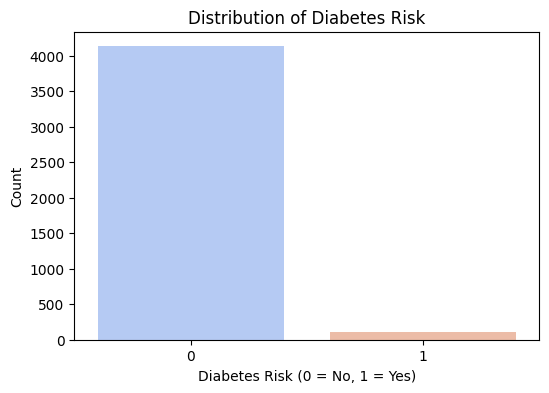

In [56]:
# Visualize diabetes risk distribution
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', hue='diabetes', data=df, palette='coolwarm', legend=False)
plt.title('Distribution of Diabetes Risk')
plt.xlabel('Diabetes Risk (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

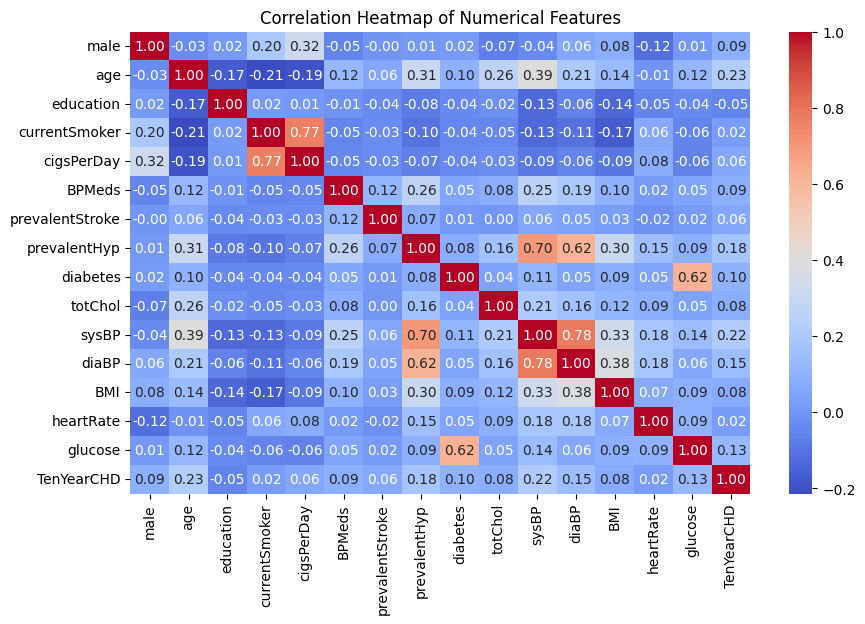

In [57]:
# Correlation heatmap (numerical features only
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [58]:
# Drop unnecessary columns (if present)
if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])

# Handling missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

            Feature  Importance
13          glucose    1.810358
10            diaBP    0.316216
1               age    0.293262
9             sysBP    0.272668
11              BMI    0.270882
6   prevalentStroke    0.266731
7      prevalentHyp    0.183170
0              male    0.120932
8           totChol    0.093099
3     currentSmoker    0.070621
5            BPMeds    0.064668
4        cigsPerDay    0.044176
14       TenYearCHD    0.043901
2         education    0.021721
12        heartRate    0.019935


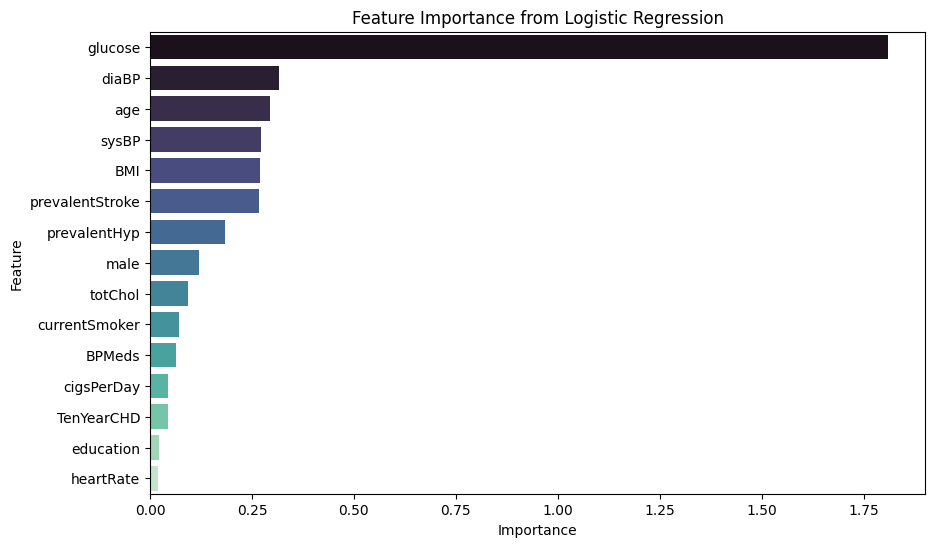

In [59]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X = df.drop(columns=['diabetes'])
X_scaled = scaler.fit_transform(X)

# Train temporary logistic regression model
model_temp = LogisticRegression(max_iter=1000)
model_temp.fit(X_scaled, y)

# Feature importance (coefficients)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model_temp.coef_[0])
}).sort_values(by='Importance', ascending=False)

print(importance)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance, hue='Feature', palette='mako')
plt.title('Feature Importance from Logistic Regression')
plt.show()

In [60]:
from sklearn.model_selection import train_test_split
# Select top features based on analysis
top_features = ['glucose', 'diaBP', 'age', 'sysBP', 'BMI']

# Define X and y using only the important ones
X = df[top_features]
y = df['diabetes']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training
Train a **Logistic Regression** model to predict diabetes risk.

In [61]:
from sklearn.metrics import confusion_matrix

# Train a Logistic Regression model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9905660377358491

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       826
           1       1.00      0.64      0.78        22

    accuracy                           0.99       848
   macro avg       1.00      0.82      0.89       848
weighted avg       0.99      0.99      0.99       848


Confusion Matrix:
 [[826   0]
 [  8  14]]
